# Demographic Analysis

Reproduces the demographic tables and figures in the paper's *Demographic* subsection:
Table 5 (countries), Table 6 (educational level), Table 7 (DS experience),
Table 8 (organization type), Table 9 (organization size), Figure 2 (DS framework
awareness and adoption), and Figure 3 (DS vs SE experience heatmap).

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import sys, os
sys.path.insert(0, os.path.abspath('.'))
from analysis_utils import load_data

warnings.filterwarnings('ignore')
df = load_data()
N  = len(df)
print(f'Dataset loaded: {N} respondents, {len(df.columns)} columns')

Dataset loaded: 112 respondents, 452 columns



## Demographic Analysis (Tables 5–9)

This section reproduces the demographic tables in the paper's *Demographic*
subsection: Table 5 (countries), Table 6 (educational level), Table 7 (DS
experience), Table 8 (organization type), and Table 9 (organization size) of
the 117 survey participants.


In [2]:
def _with_total(counts: pd.Series, label_col: str, total: int = N) -> pd.DataFrame:
    """Build a (Label, Count, Percentage) frame with a Total row."""
    out = pd.DataFrame({
        label_col:    counts.index,
        'Count':      counts.values,
        'Percentage': (counts.values / total * 100).round(2),
    })
    out.loc[len(out)] = ['Total', counts.sum(),
                         round(counts.sum() / total * 100, 2)]
    return out

### Table 5: Countries of survey participants


In [3]:
COUNTRY_RENAME = {'Ireland {Republic}': 'Ireland'}
country_counts = (
    df['country_Response']
      .replace(COUNTRY_RENAME)
      .value_counts(dropna=False)
)
country_df = _with_total(country_counts, 'Country')
display(country_df)

,Country,Count,Percentage
0,Thailand,70,62.50
1,India,13,11.61
2,Italy,6,5.36
3,South Africa,5,4.46
4,Australia,4,3.57
5,Spain,3,2.68
6,Portugal,2,1.79
7,Mexico,2,1.79
8,Austria,2,1.79
9,United States,1,0.89


### Table 6: Educational level


In [4]:
EDU_MAP = {
    'ต่ำกว่าปริญญาตรี':         "Below bachelor's degree",
    'ปริญญาตรีหรือเท่าเทียม':   'Bachelor',
    'ปริญญาโทหรือเท่าเทียม':    "Master's",
    'ปริญญาเอกหรือเท่าเทียม':   'Doctorate',
}
EDU_ORDER = ["Below bachelor's degree", 'Bachelor', "Master's", 'Doctorate']

edu_counts = (
    df['education_level_Response']
      .map(EDU_MAP)
      .value_counts()
      .reindex(EDU_ORDER, fill_value=0)
)
edu_df = _with_total(edu_counts, 'Educational Level')
display(edu_df)

,Educational Level,Count,Percentage
0,Below bachelor's degree,4,3.57
1,Bachelor,51,45.54
2,Master's,48,42.86
3,Doctorate,9,8.04
4,Total,112,100.00


### Table 7: Data science experience


In [5]:
DS_EXP_LABELS = {
    1: 'Less than 1 year',
    2: '1--5 years',
    3: '6--10 years',
    4: 'More than 10 years',
}
DS_EXP_ORDER = list(DS_EXP_LABELS.values())

ds_counts = (
    df['ds_exp']
      .map(DS_EXP_LABELS)
      .value_counts()
      .reindex(DS_EXP_ORDER, fill_value=0)
)
ds_df = _with_total(ds_counts, 'DS Experience')
display(ds_df)

,DS Experience,Count,Percentage
0,Less than 1 year,23,20.54
1,1--5 years,60,53.57
2,6--10 years,18,16.07
3,More than 10 years,11,9.82
4,Total,112,100.00


### Table 8: Organization type


In [6]:
ORG_TYPE_RENAME = {'อื่นๆ (โปรดระบุ)': 'Others'}
ORG_TYPE_ORDER  = [
    'In-house data science/data team',
    'Data consultant',
    'Software house',
    'Others',
]

org_counts = (
    df['organization_type_Response']
      .replace(ORG_TYPE_RENAME)
      .value_counts()
      .reindex(ORG_TYPE_ORDER, fill_value=0)
)
org_df = _with_total(org_counts, 'Organization Type')
display(org_df)

,Organization Type,Count,Percentage
0,In-house data science/data team,51,45.54
1,Data consultant,26,23.21
2,Software house,19,16.96
3,Others,16,14.29
4,Total,112,100.00


### Table 9: Organization size


In [7]:
SIZE_ORDER = [
    '0 - 9',
    '10 - 99',
    '100 - 999',
    '1,000 - 9,999',
    '10,000 - 99,999',
    '100,000 or above',
]
# Tolerate either '10 - 99' (with spaces) or '10-99' (no spaces) in legacy data.
SIZE_RENAME = {'10-99': '10 - 99'}

size_counts = (
    df['organization_size_Response']
      .replace(SIZE_RENAME)
      .value_counts()
      .reindex(SIZE_ORDER, fill_value=0)
)
size_df = _with_total(size_counts, 'Organization Size')
display(size_df)

,Organization Size,Count,Percentage
0,0 - 9,7,6.25
1,10 - 99,26,23.21
2,100 - 999,27,24.11
3,"1,000 - 9,999",36,32.14
4,"10,000 - 99,999",14,12.50
5,"100,000 or above",2,1.79
6,Total,112,100.00



### Figure 3: DS vs SE experience heatmap

A 4×4 heatmap of participant counts grouped by data-science experience
(rows) and software-engineering experience (columns). Following the paper,
participants who selected "no SE experience" are merged into the
"Less than 1 year" SE bucket so both axes share the same four-level scale.
Kendall's Tau-b on the resulting ordinal pair quantifies the diagonal
trend.


Kendall's Tau-b = 0.5103   (p = 6.8576e-10, n = 112)
Saved: /Users/chaiyong/Downloads/2023_SE4DS/EMSE/ds-se-counts-heatmap.pdf


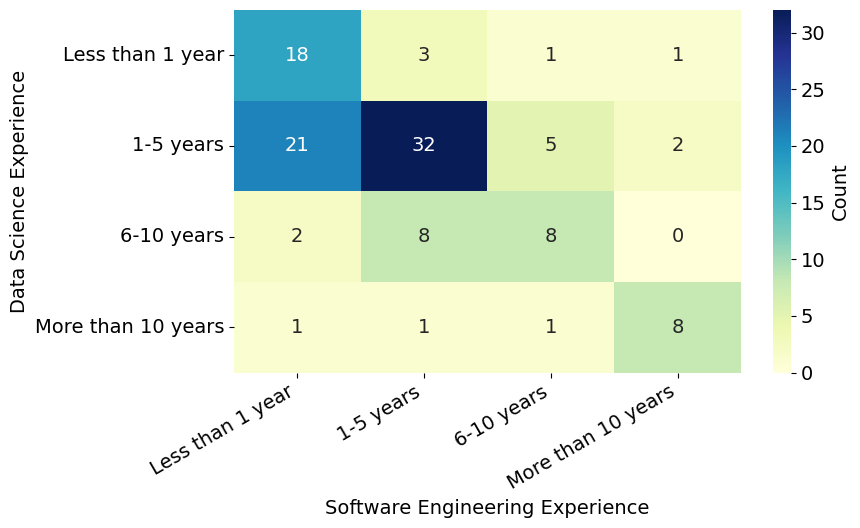

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

EXP_LABELS = ['Less than 1 year', '1-5 years', '6-10 years', 'More than 10 years']

# Merge "no SE experience" (se_exp=0) into "Less than 1 year" (se_exp=1)
# to obtain a 4x4 ordinal pair matching the DS-experience scale.
se_exp_4 = df['se_exp'].replace({0: 1})

ct = pd.crosstab(df['ds_exp'], se_exp_4).reindex(
    index=[1, 2, 3, 4], columns=[1, 2, 3, 4], fill_value=0
)
ct.index   = EXP_LABELS
ct.columns = EXP_LABELS

# Kendall's Tau-b on the ordinal pair 
tau, p = stats.kendalltau(df['ds_exp'], se_exp_4)
print(f"Kendall's Tau-b = {tau:.4f}   (p = {p:.4e}, n = {len(df)})")

plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.heatmap(
    ct,
    annot=True, fmt='d',
    cmap='YlGnBu',
    cbar_kws={'label': 'Count'},
    annot_kws={'size': 14},
    linewidths=0,
    ax=ax,
)
ax.set_xlabel('Software Engineering Experience', fontsize=14)
ax.set_ylabel('Data Science Experience', fontsize=14)
plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=14)
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=14)
fig.tight_layout()

# Save next to the .tex source so jss.tex picks it up unchanged.
out_path = Path('..') / 'ds-se-counts-heatmap.pdf'
fig.savefig(out_path, bbox_inches='tight')
print(f"Saved: {out_path.resolve()}")

plt.show()


### Figure 2: DS-framework awareness and adoption (two pies)

Reproduces the two-panel Figure 2 in the JSS paper.

* **Panel (a)** — *Awareness*: aware-and-using vs. aware-but-not-using vs.
  not-aware, computed over all 117 respondents.
* **Panel (b)** — *Adoption*: which framework respondents actually use,
  computed over the 88 respondents who answered the framework question.
  The 13 free-text *Others* responses are split (per the paper text) into
  7 *Not use*, 6 *Others* (Scrum/Tableau/Snowflake/Snowplow), and 0
  *Not specified*; the remaining 4 *Not specified* are aware respondents
  who left the framework question blank.


Awareness counts (n = 112):
knows_ds_framework_Response
Aware and currently using    48
Aware but never use          33
Not aware                    31
Name: count, dtype: int64
Saved: /Users/chaiyong/Downloads/2023_SE4DS/EMSE/ds-framework-knowledge-pie-crop.pdf


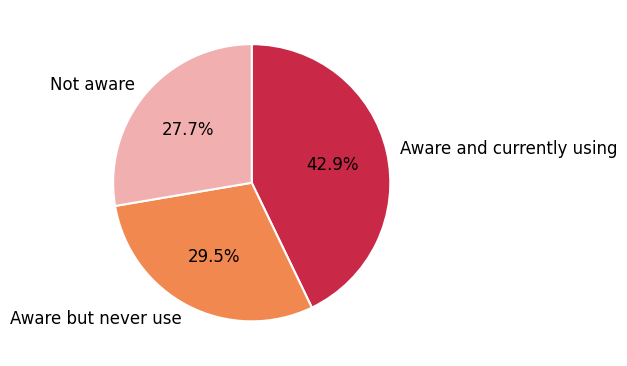

In [9]:
import matplotlib.pyplot as plt
from pathlib import Path

# ---------------------------------------------------------------------------
# Panel (a): Awareness
# ---------------------------------------------------------------------------
AWARENESS_LABELS = {
    'รู้จักและใช้งาน':            'Aware and currently using',
    'รู้จักแต่ไม่ได้ใช้งาน':      'Aware but never use',
    'ไม่รู้จัก':                  'Not aware',
}
AWARENESS_ORDER  = ['Aware and currently using',
                    'Aware but never use',
                    'Not aware']
# Three-tone red/orange/pink palette matching the original figure.
AWARENESS_COLORS = ['#C92846', '#F08850', '#F1B0AF']

aware_counts = (
    df['knows_ds_framework_Response']
      .map(AWARENESS_LABELS)
      .value_counts()
      .reindex(AWARENESS_ORDER, fill_value=0)
)
print('Awareness counts (n = {}):'.format(aware_counts.sum()))
print(aware_counts)

fig_a, ax_a = plt.subplots(figsize=(7, 4.5))
ax_a.pie(
    aware_counts.values,
    labels=aware_counts.index,
    colors=AWARENESS_COLORS,
    autopct='%.1f%%',
    startangle=90,
    counterclock=False,
    textprops={'fontsize': 12},
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
)
ax_a.set_aspect('equal')
out_a = Path('..') / 'ds-framework-knowledge-pie-crop.pdf'
fig_a.savefig(out_a, bbox_inches='tight')
print(f'Saved: {out_a.resolve()}')
plt.show()

Adoption counts (n = 83):
  Microsoft TDSP      34   40.96%
  CRISP-DM            32   38.55%
  Not use              7    8.43%
  Others               6    7.23%
  Not specified        4    4.82%
Saved: /Users/chaiyong/Downloads/2023_SE4DS/EMSE/ds-framework-used-pie.pdf


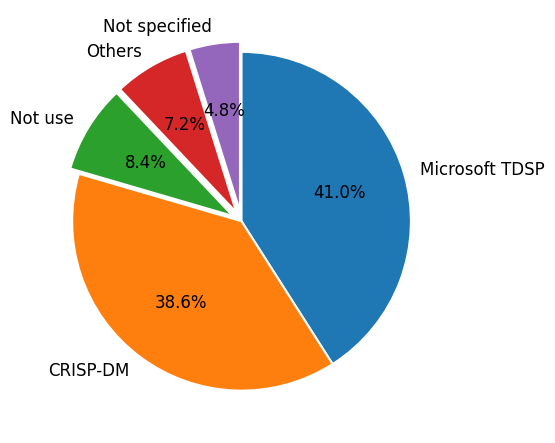

In [11]:
# ---------------------------------------------------------------------------
# Panel (b): Adoption
# ---------------------------------------------------------------------------
# The raw column has only three response options (MS TDSP, CRISP-DM,
# 'Others — please specify') plus NaN. The paper breaks 'Others' down by
# manually coding the 13 free-text answers, and treats NaN among aware
# respondents as 'Not specified'.

OTHERS_TH = 'อื่นๆ (โปรดระบุ)'
n_ms_tdsp   = (df['ds_framework_used_Response'] == 'Microsoft TDSP').sum()
n_crisp_dm  = (df['ds_framework_used_Response'] == 'CRISP-DM').sum()
n_others_tot = (df['ds_framework_used_Response'] == OTHERS_TH).sum()

# Manual split of the 13 'Others' free-text answers (paper, Sec. RQ1):
#   - 7 said they do not use any framework        -> 'Not use'
#   - 3 listed unrelated tools (Scrum, Tableau,
#     Snowflake, Snowplow) + 2 in-house + 1 generic = 6 -> 'Others'
n_not_use = 7
n_others  = 6
assert n_not_use + n_others == n_others_tot, (
    f'manual split must total {n_others_tot}, got {n_not_use + n_others}'
)

# Aware respondents who left the question blank -> 'Not specified'
aware_mask    = df['knows_ds_framework_Response'].isin([
    'รู้จักและใช้งาน', 'รู้จักแต่ไม่ได้ใช้งาน',
])
n_not_spec    = (aware_mask & df['ds_framework_used_Response'].isna()).sum()

ADOPTION = {
    'Microsoft TDSP': n_ms_tdsp,
    'CRISP-DM':       n_crisp_dm,
    'Not use':        n_not_use,
    'Others':         n_others,
    'Not specified':  n_not_spec,
}
total = sum(ADOPTION.values())
print(f'Adoption counts (n = {total}):')
for k, v in ADOPTION.items():
    print(f'  {k:18s} {v:3d}   {v/total*100:5.2f}%')

# Default tab10 palette (matches the original figure):
# blue, orange, green, red, purple
ADOPT_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
EXPLODE       = [0.0, 0.0, 0.06, 0.06, 0.06]   # pull out the smaller slices

fig_b, ax_b = plt.subplots(figsize=(7, 5.5))
ax_b.pie(
    list(ADOPTION.values()),
    labels=list(ADOPTION.keys()),
    colors=ADOPT_COLORS,
    explode=EXPLODE,
    autopct='%.1f%%',
    startangle=90,
    counterclock=False,
    textprops={'fontsize': 12},
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
)
ax_b.set_aspect('equal')
out_b = Path('..') / 'ds-framework-used-pie.pdf'
fig_b.savefig(out_b, bbox_inches='tight')
print(f'Saved: {out_b.resolve()}')
plt.show()